Project Title

Fashion Item Classification Using Convolutional Neural Networks (CNN)

Objective

The objective of this project is to build a Convolutional Neural Network (CNN) model capable of classifying fashion items from grayscale images into different categories such as shirts, shoes, bags, dresses, and more.

The project uses the Fashion MNIST dataset provided by TensorFlow.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


In [6]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [7]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


In [8]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

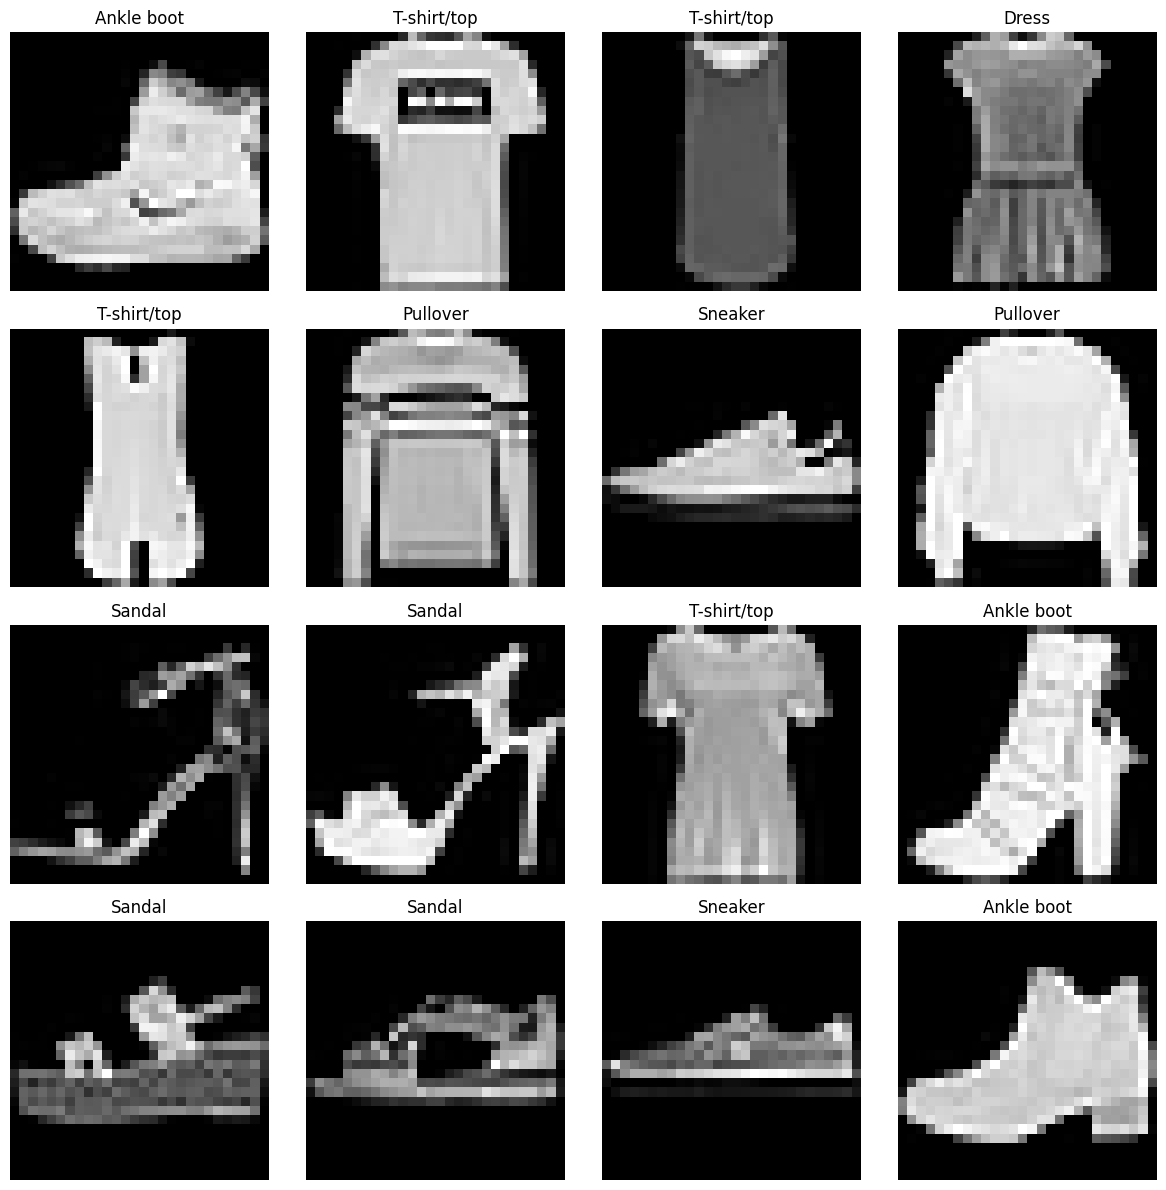

In [9]:
plt.figure(figsize=(12,12))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

In [12]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# First Pooling Layer
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Hidden Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

c:\Users\deeks\OneDrive\Attachments\Desktop\tek_works\CNN\tfenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.7825 - loss: 0.6091 - val_accuracy: 0.8531 - val_loss: 0.3994
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.8548 - loss: 0.4066 - val_accuracy: 0.8802 - val_loss: 0.3389
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8720 - loss: 0.3545 - val_accuracy: 0.8829 - val_loss: 0.3210
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8840 - loss: 0.3228 - val_accuracy: 0.8965 - val_loss: 0.2895
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8918 - loss: 0.2989 - val_accuracy: 0.8927 - val_loss: 0.2876
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.8981 - loss: 0.2776 - val_accuracy: 0.8974 - val_loss: 0.2840
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.9053 - loss: 0.2620 - val_accuracy: 0.9030 - val_loss: 0.2627
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9093 - loss: 0.2466 - 

In [16]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9093 - loss: 0.2459
Test Loss: 0.245895653963089
Test Accuracy: 0.9093000292778015


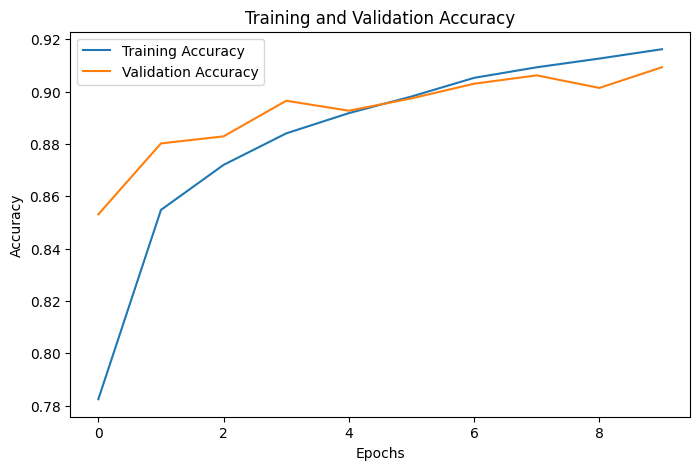

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

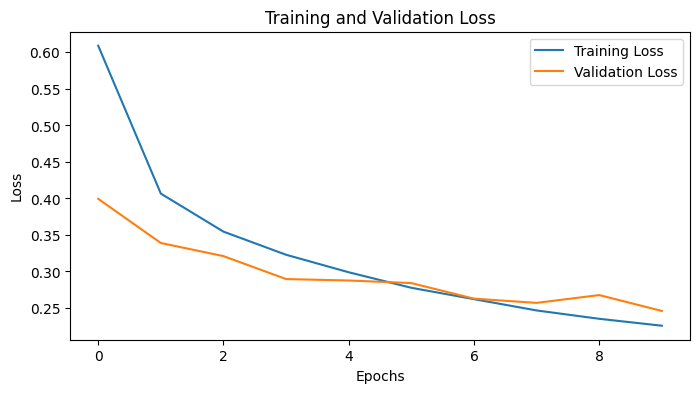

In [18]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [19]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


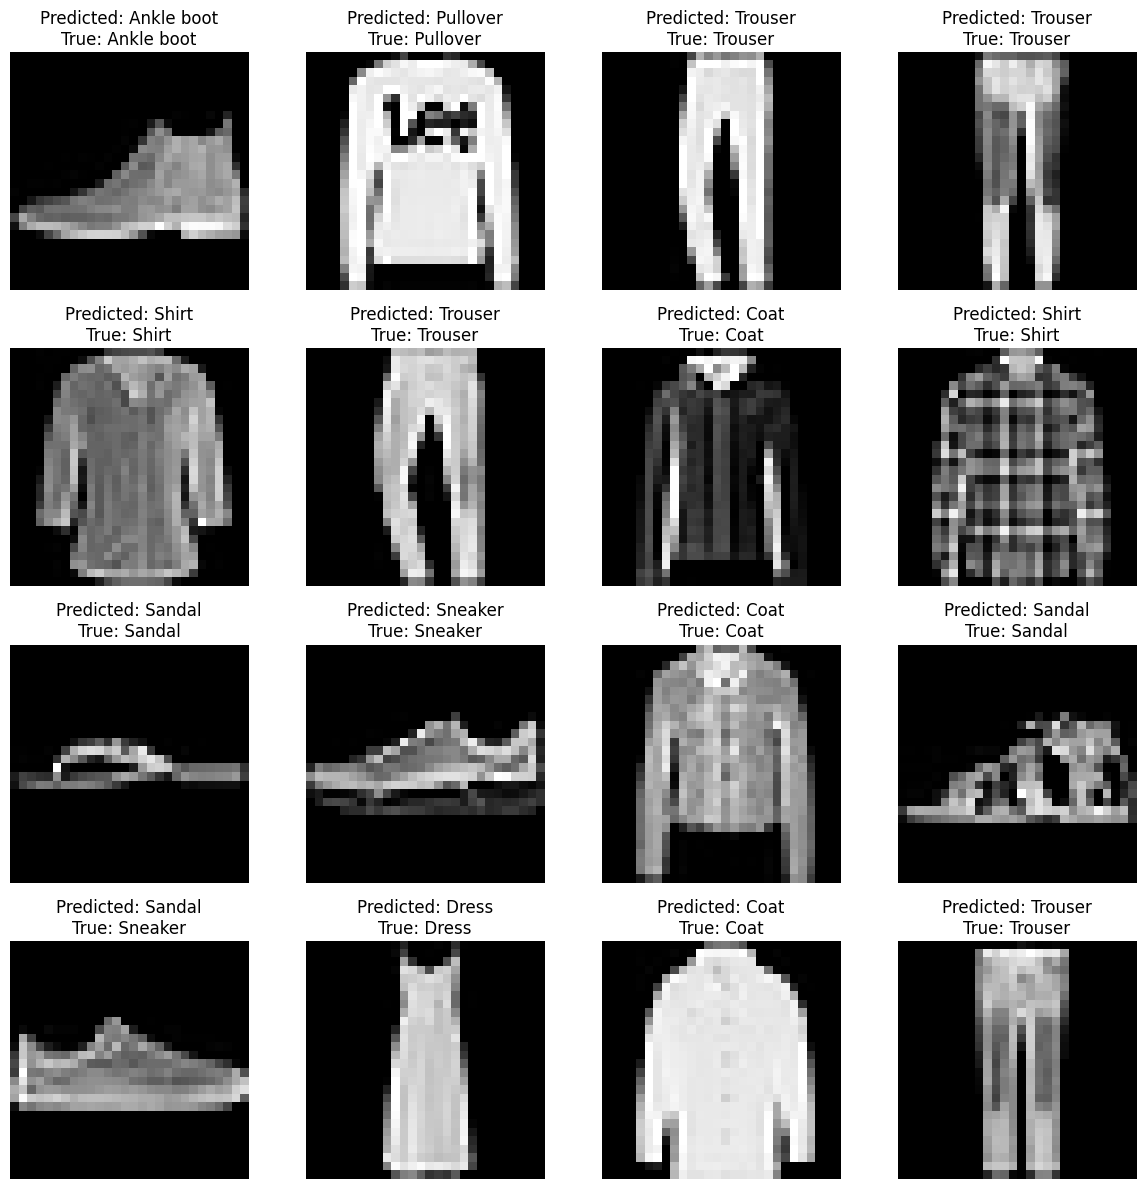

In [20]:
plt.figure(figsize=(12,12))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"Predicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np

In [22]:
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(y_test, predicted_classes, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.89      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.85      0.89      0.87      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.86      0.85      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.68      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [23]:
cm = confusion_matrix(y_test, predicted_classes)

In [24]:
model.save('fashion_mnist_cnn.h5')

In [25]:
from tensorflow.keras.models import load_model

loaded_model = load_model('fashion_mnist_cnn.h5')

In [26]:
sample_image = x_test[0].reshape(1,28,28,1)

prediction = loaded_model.predict(sample_image)

predicted_label = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Predicted Class: Ankle boot
